In [1]:
# Note: After you run this cell, the training and test data will be available in
# the file browser. (Click the folder icon on the left to view it)
#
# If you don't see the data after the cell completes, click the refresh button
# in the file browser (folder icon with circular arrow)

# First, let's download and unzip the data
!echo "Downloading files..."
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/training1.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/training2.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/holdout.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/mini_holdout.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/mini_holdout_answers.csv

!echo "Unzipping files..."
!unzip -q /content/training1.zip
!unzip -q /content/training2.zip
!unzip -q /content/holdout.zip
!unzip -q /content/mini_holdout.zip

# Combine the two traning directories
!echo "Merging training data..."
!mkdir /content/training
!mv /content/training1/* /content/training
!mv /content/training2/* /content/training

# Cleanup
!echo "Cleaning up..."
!rmdir /content/training1
!rmdir /content/training2
!rm training1.zip
!rm training2.zip
!rm holdout.zip
!rm mini_holdout.zip

!echo "Data ready."

Unzipping files...
Merging training data...
Cleaning up...
Data ready.


In [2]:
# Import libraries
!pip install tensorflow
import os
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# We're using keras' ImageDataGenerator class to load our image data.
# See (https://keras.io/api/preprocessing/image/#imagedatagenerator-class) for details
#
# A couple of things to note:
# 1. We're specifying a number for the seed, so we'll always get the same shuffle and split of our images.
# 2. Class names are inferred automatically from the image subdirectory names.
# 3. We're splitting the training data into 80% training, 20% validation.


training_dir = '/content/training/'
image_size = (100, 100)

# Split up the training data images into training and validations sets
# We'll use and ImageDataGenerator to do the splits
# ImageDataGenerator can also be used to do preprocessing and agumentation on the files as can be seen with rescale

train_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=.2
        )
validation_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=.2
        )

train_generator = train_datagen.flow_from_directory(
        training_dir,
        target_size = image_size,
        subset="training",
        batch_size=32,
        class_mode='sparse',
        seed=42,shuffle=True)
validation_generator = validation_datagen.flow_from_directory(
        training_dir,
        target_size=image_size,
        batch_size=32,
        class_mode='sparse',
        subset="validation",
        seed=42)



Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.


In [4]:
#these might come in handy
target_names = ['Speed_20', 'Speed_30', 'Speed_50', 'Speed_60', 'Speed_70',
               'Speed_80','Speed_Limit_Ends', 'Speed_100', 'Speed_120', 'Overtaking_Prohibited',
               'Overtakeing_Prohibited_Trucks', 'Priority', 'Priority_Road_Ahead', 'Yield', 'STOP',
               'Entry_Forbidden', 'Trucks_Forbidden', 'No_Entry(one-way traffic)', 'General Danger(!)', 'Left_Curve_Ahead',
               'Right_Curve_Ahead', 'Double_Curve', 'Poor_Surface_Ahead', 'Slippery_Surface_Ahead', 'Road_Narrows_On_Right',
               'Roadwork_Ahead', 'Traffic_Light_Ahead', 'Warning_Pedestrians', 'Warning_Children', 'Warning_Bikes',
               'Ice_Snow', 'Deer_Crossing', 'End_Previous_Limitation', 'Turning_Right_Compulsory', 'Turning_Left_Compulsory',
               'Ahead_Only', 'Straight_Or_Right_Mandatory', 'Straight_Or_Left_Mandatory', 'Passing_Right_Compulsory', 'Passing_Left_Compulsory',
               'Roundabout', 'End_Overtaking_Prohibition', 'End_Overtaking_Prohibition_Trucks']

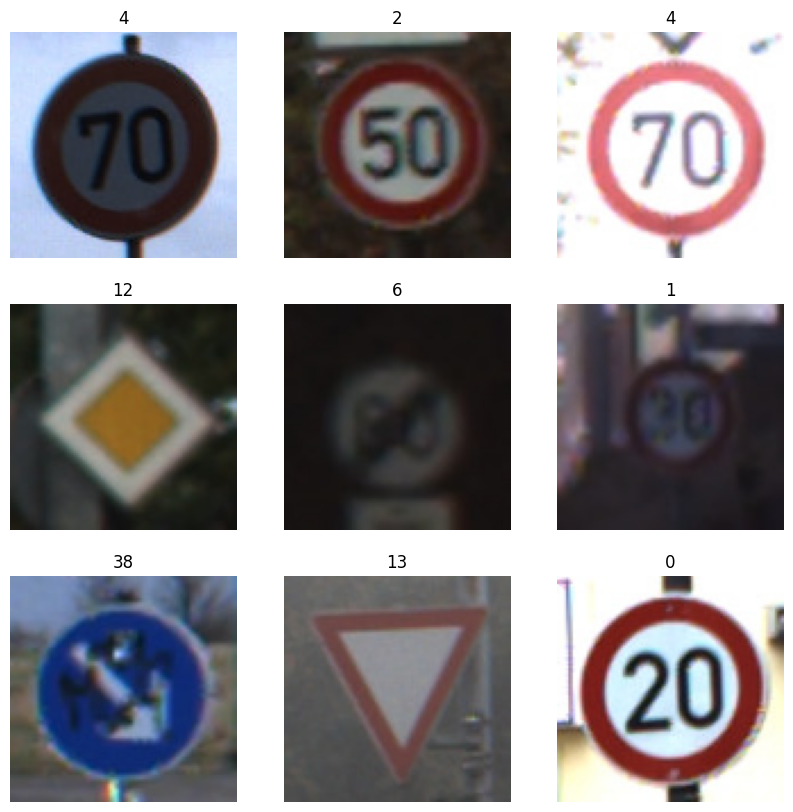

In [5]:
# View 9 images and their class labels
plt.figure(figsize=(10, 10))
images, labels = next(train_generator)  # Assuming train_generator is a generator
batch_size = images.shape[0]

for i in range(min(9, batch_size)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow((images[i] * 255).astype("uint8"))
    plt.title(int(labels[i]))
    plt.axis("off")

plt.show()

Num GPUs Available:  1
['00035', '00019', '00033', '00002', '00040', '00027', '00038', '00031', '00029', '00034', '00021', '00032', '00018', '00008', '00041', '00007', '00012', '00013', '00015', '00010', '00028', '00009', '00037', '00011', '00030', '00014', '00016', '00036', '00020', '00042', '00026', '00017', '00023', '00024', '00039', '00003', '00004', '00001', '00005', '00022', '00025', '00000', '00006']
Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 96, 96, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 21, 21, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 112896)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │     7,225,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 43)             │         2,795 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 43)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,617,643 (29.06 MB)

 Trainable params: 7,617,131 (29.06 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 55s 48ms/step - accuracy: 0.6666 - loss: 2.1746 - val_accuracy: 0.8702 - val_loss: 1.4192
Epoch 2/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.7713 - loss: 1.1497 - val_accuracy: 0.7536 - val_loss: 5.0882
Epoch 3/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 43s 43ms/step - accuracy: 0.7786 - loss: 1.0179 - val_accuracy: 0.9195 - val_loss: 1.1396
Epoch 4/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.7836 - loss: 0.9726 - val_accuracy: 0.2862 - val_loss: 64.0301
Epoch 5/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.7912 - loss: 0.8994 - val_accuracy: 0.9364 - val_loss: 1.0857


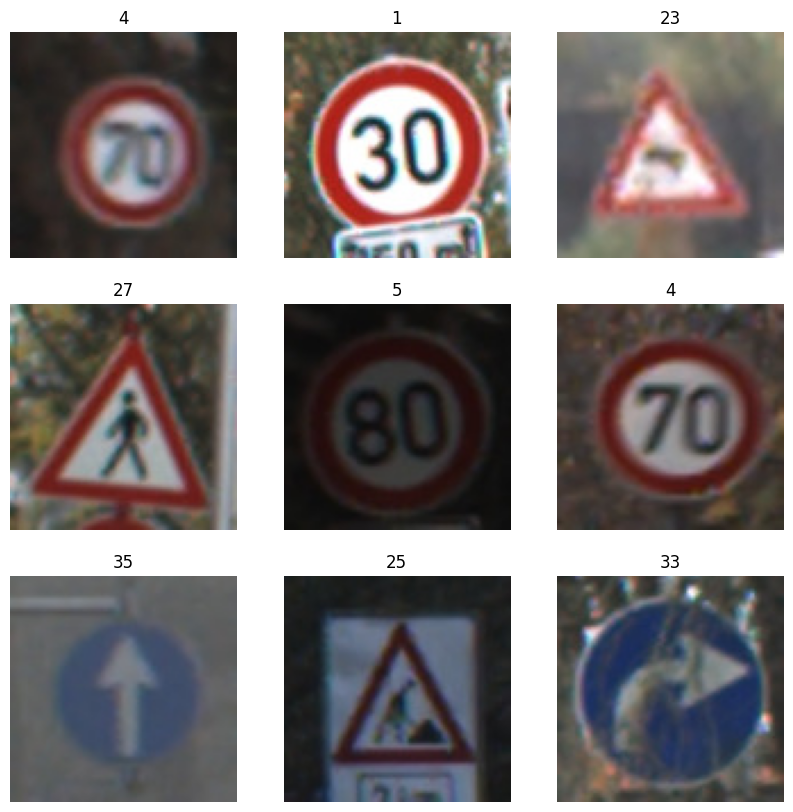

246/246 - 5s - 19ms/step - accuracy: 0.9364 - loss: 1.0857
Test Loss: 1.0857
Test Accuracy: 0.9364
246/246 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step
Confusion Matrix: 
[[ 31   7   1 ...   0   0   0]
 [  0 415   4 ...   0   0   0]
 [  0   8 392 ...   0   0   0]
 ...
 [  0   0   8 ...  50   0   0]
 [  0   0   0 ...   0  48   0]
 [  0   0   0 ...   0   0  48]]


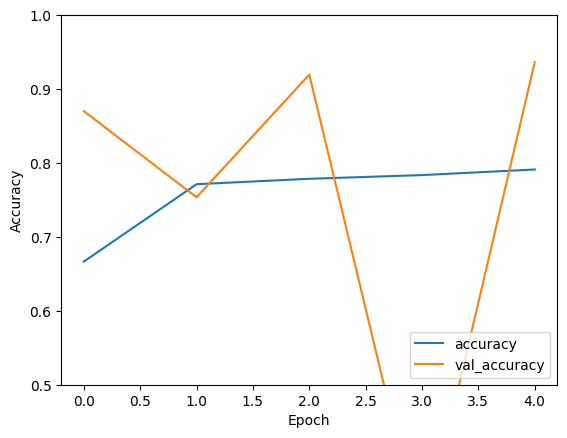

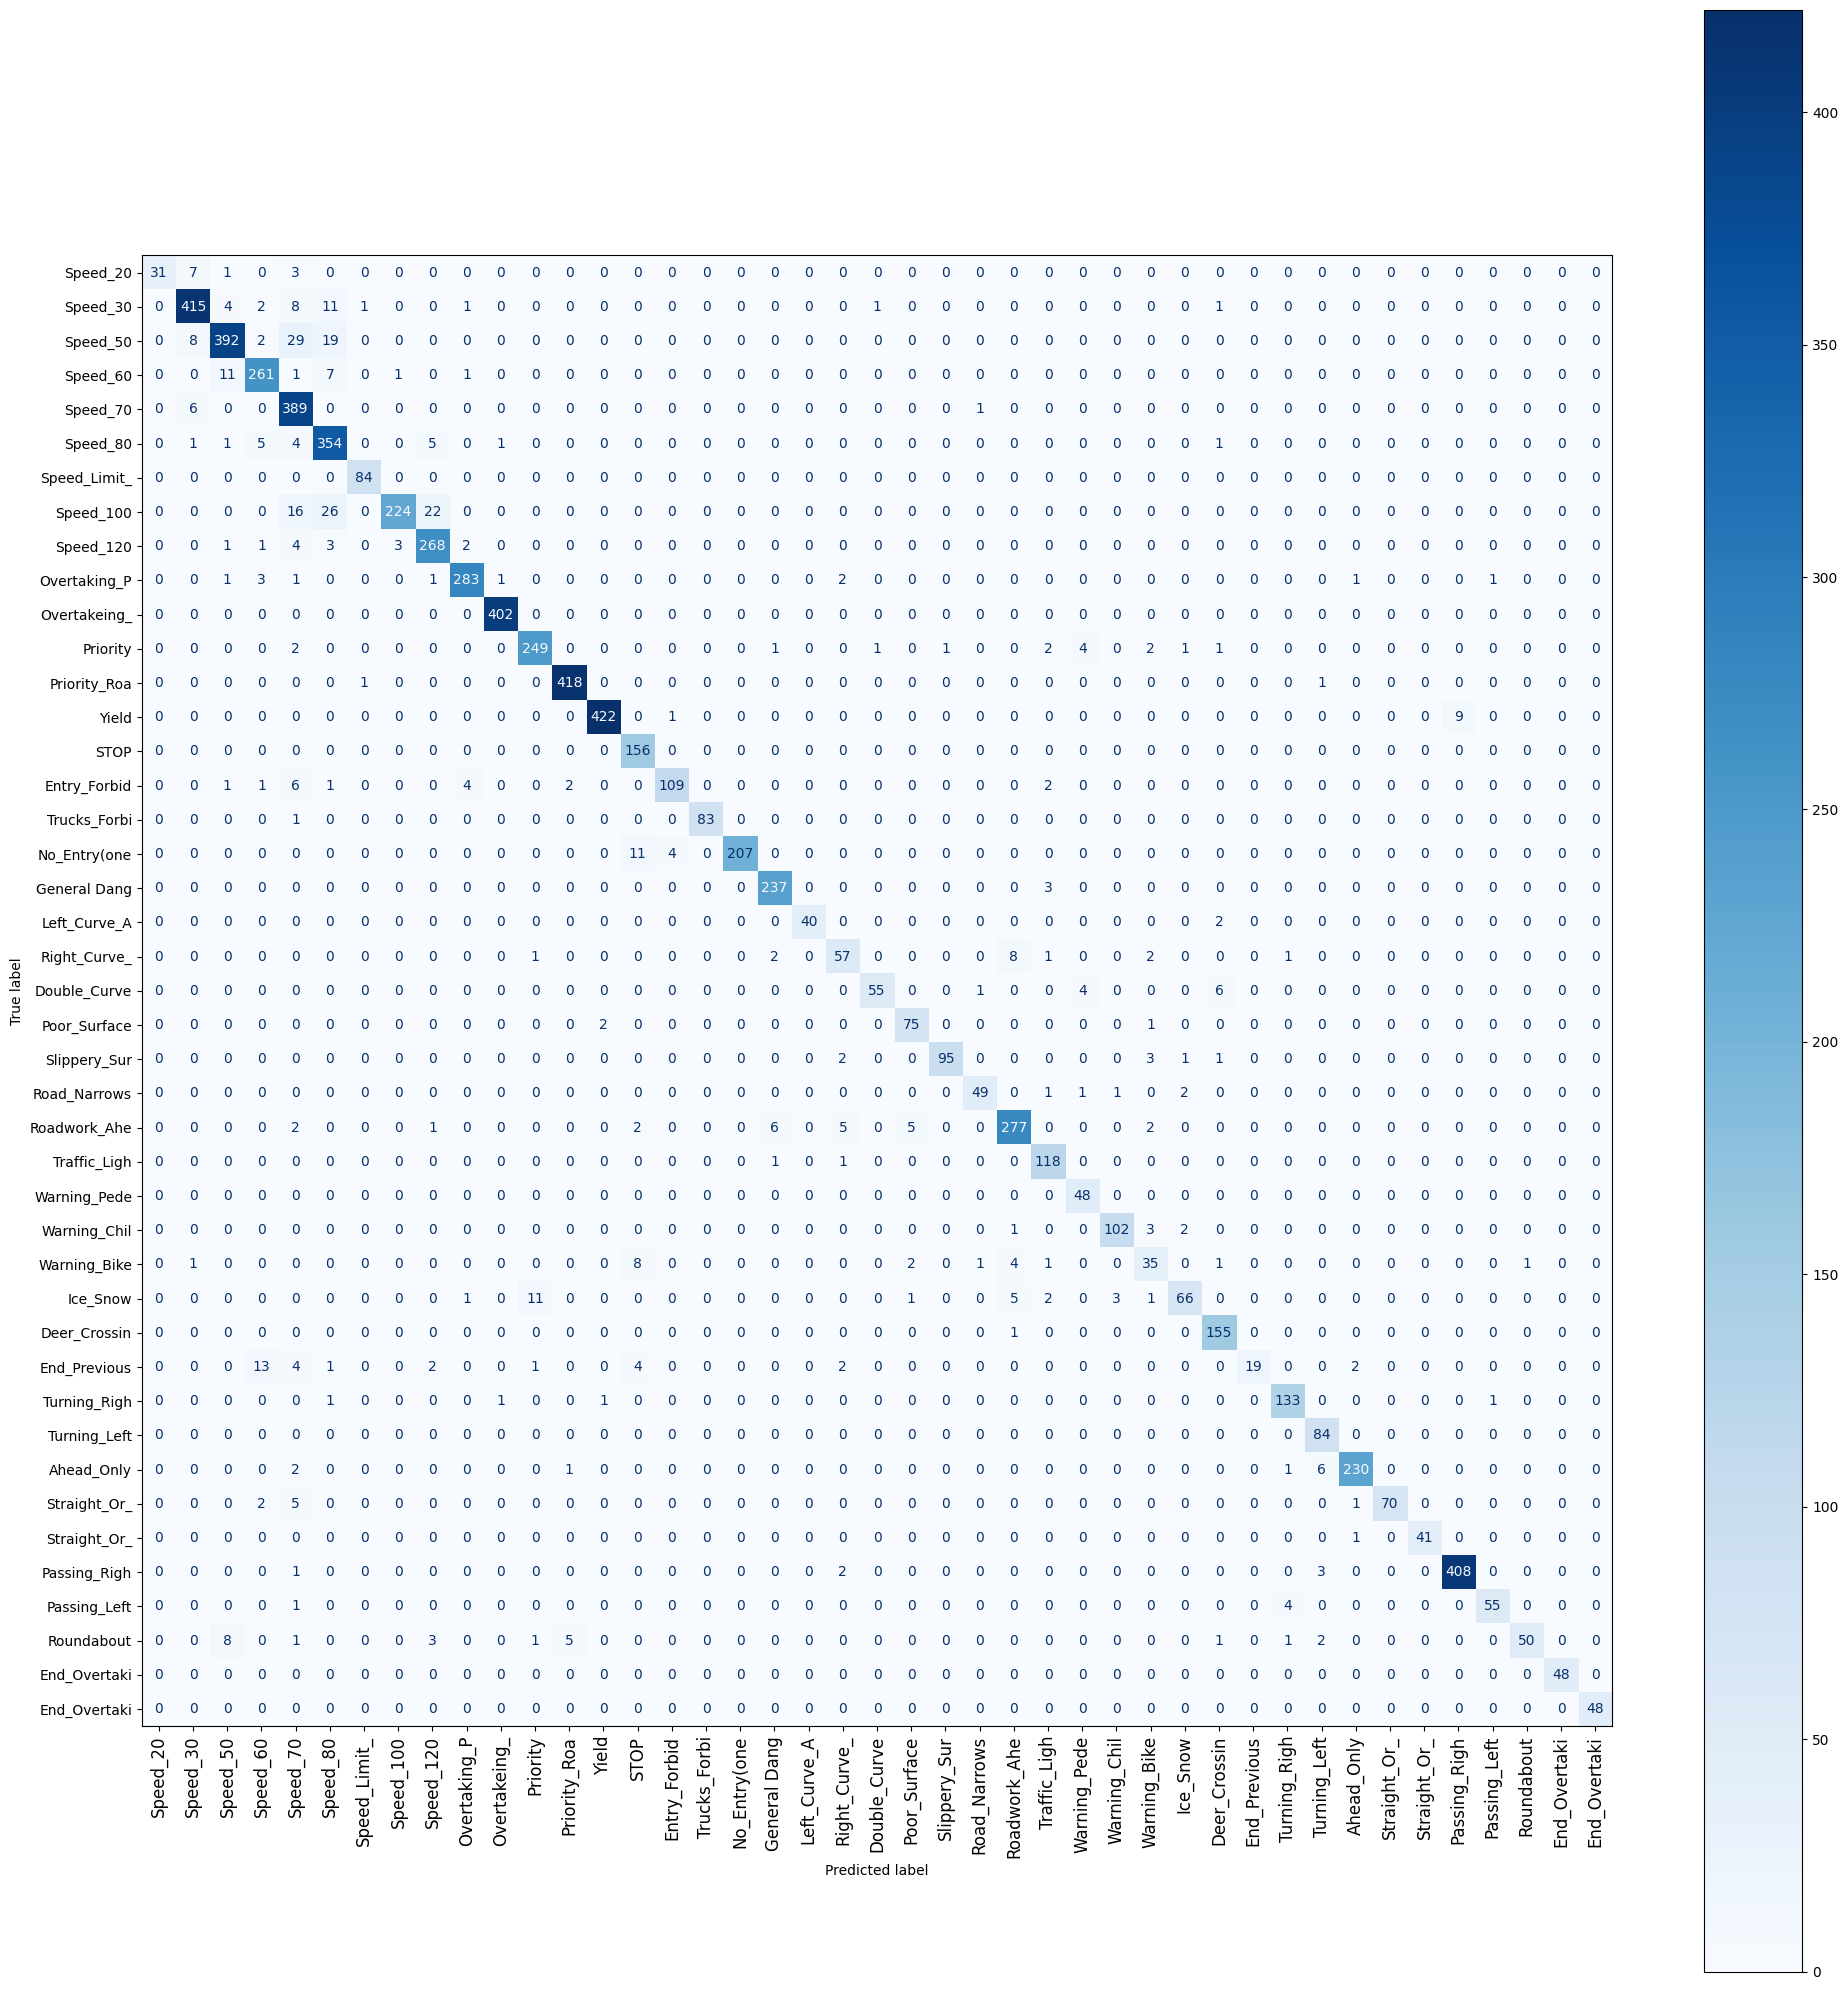

Classification Report: 
                                   precision    recall  f1-score   support

                         Speed_20       1.00      0.74      0.85        42
                         Speed_30       0.95      0.93      0.94       444
                         Speed_50       0.93      0.87      0.90       450
                         Speed_60       0.90      0.93      0.91       282
                         Speed_70       0.81      0.98      0.89       396
                         Speed_80       0.84      0.95      0.89       372
                 Speed_Limit_Ends       0.98      1.00      0.99        84
                        Speed_100       0.98      0.78      0.87       288
                        Speed_120       0.89      0.95      0.92       282
            Overtaking_Prohibited       0.97      0.96      0.97       294
    Overtakeing_Prohibited_Trucks       0.99      1.00      1.00       402
                         Priority       0.95      0.94      0.94       264


In [12]:
# Build a model...
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, Input
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from tensorflow.keras.preprocessing import image_dataset_from_directory

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(os.listdir("/content/training"))

### Training data
training_dir = '/content/training/'
image_size = (100, 100)

train_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=.2
        )
validation_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=.2
        )

train_generator = train_datagen.flow_from_directory(
        training_dir,
        target_size = image_size,
        subset="training",
        batch_size=32,
        class_mode='sparse',
        seed=42,shuffle=True)
validation_generator = validation_datagen.flow_from_directory(
        training_dir,
        target_size=image_size,
        batch_size=32,
        class_mode='sparse',
        subset="validation",
        seed=42,
        shuffle=False)

target_names = ['Speed_20', 'Speed_30', 'Speed_50', 'Speed_60', 'Speed_70',
               'Speed_80','Speed_Limit_Ends', 'Speed_100', 'Speed_120', 'Overtaking_Prohibited',
               'Overtakeing_Prohibited_Trucks', 'Priority', 'Priority_Road_Ahead', 'Yield', 'STOP',
               'Entry_Forbidden', 'Trucks_Forbidden', 'No_Entry(one-way traffic)', 'General Danger(!)', 'Left_Curve_Ahead',
               'Right_Curve_Ahead', 'Double_Curve', 'Poor_Surface_Ahead', 'Slippery_Surface_Ahead', 'Road_Narrows_On_Right',
               'Roadwork_Ahead', 'Traffic_Light_Ahead', 'Warning_Pedestrians', 'Warning_Children', 'Warning_Bikes',
               'Ice_Snow', 'Deer_Crossing', 'End_Previous_Limitation', 'Turning_Right_Compulsory', 'Turning_Left_Compulsory',
               'Ahead_Only', 'Straight_Or_Right_Mandatory', 'Straight_Or_Left_Mandatory', 'Passing_Right_Compulsory', 'Passing_Left_Compulsory',
               'Roundabout', 'End_Overtaking_Prohibition', 'End_Overtaking_Prohibition_Trucks']


### Model Prep
model = models.Sequential()
model.add(Input(shape=(100, 100, 3))) # Explicit Input layer
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(256, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(43, activation='softmax'))
model.add(layers.Dropout(0.2))
model.summary()


### Model
model.compile(optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['accuracy'])

history = model.fit(
    train_generator,
    epochs=5,
    validation_data=validation_generator
)


### Show model statistics
plt.figure(figsize=(10, 10))
images, labels = next(train_generator)
batch_size = images.shape[0]

for i in range(min(9, batch_size)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow((images[i] * 255).astype("uint8"))
    plt.title(int(labels[i]))
    plt.axis("off")
plt.show()

plt.show()
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')


test_loss, test_acc = model.evaluate(validation_generator, verbose=2)
print(f"Test Loss: {test_loss:.4f}\nTest Accuracy: {test_acc:.4f}")

predictions = model.predict(validation_generator)
predictions_new = np.argmax(predictions,axis=1)

# Confusion matrix
cm = confusion_matrix(validation_generator.classes, predictions_new)
print(f"Confusion Matrix: \n{cm}")
short_names = [name[:12]for name in target_names]
cmd = ConfusionMatrixDisplay(cm, display_labels=short_names)
fig, ax = plt.subplots(figsize=(20,20))
cmd.plot(ax=ax, cmap="Blues", values_format='.5g')
plt.xticks(rotation=90, fontsize= 12)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Classification Report: \n{classification_report(validation_generator.classes, predictions_new, target_names=target_names)}")


### mini holdout test
test_dir = '/content/mini_holdout'

filenames = sorted([
    f for f in os.listdir(test_dir)
    if os.path.isfile(os.path.join(test_dir, f)) and f.endswith('.jpg')
])

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels=None,
    shuffle=False,
    image_size=image_size,
    batch_size=32
)
probabilities = model.predict(test_dataset)
predictions = [np.argmax(probas) for probas in probabilities]

# Test against answer
answers_url = 'https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/roadsigns/mini_holdout_answers.csv'
answers_df = pd.read_csv(answers_url)

preds_df = pd.DataFrame({
    'Filename': filenames,
    'Predicted': predictions
})

merged_df = pd.merge(answers_df, preds_df, on='Filename')
y_true = merged_df['ClassId']
y_pred = merged_df['Predicted']

print("\nHoldout Accuracy:", accuracy_score(y_true, y_pred))
print("\nHoldout Classification Report:\n", classification_report(y_true, y_pred, zero_division=0))


### holdout csv
test_dir = '/content/holdout'

test_datagen = ImageDataGenerator(rescale=1./255)
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels=None,
    shuffle=False,
    image_size=image_size,
    batch_size=32
)

probabilities = model.predict(test_dataset)
predictions = [np.argmax(probas) for probas in probabilities]

my_predictions = pd.DataFrame({'Predicted': predictions})
my_predictions.to_csv(path_or_buf="team3-module5-predictions.csv", index=False)

## Testing the model
Once you have built and trained your model, the next step is to run the mini holdout images through it and see how well your model does at making predictions for images it has never seen before.

Since loading these images and formatting them for the model can be tricky, you may find the following code useful. This code only uses your model to predict the class label for a given image. You'll still need to compare those predictions to the "ground truth" class labels in `mini_holdout_answers.csv` to evaluate how well the model does.

Previously, you were given a file that would check your results. This time you're given the answers to the first mini holdout dataset. You'll need to compare those predictions against the "ground truth" class labels in `mini_holdout_answers.csv` to evaluate how well the model does.

Make sure to use the insights gained from the mini hold out dataset in your executive summary.


```
from tensorflow.keras.preprocessing import image_dataset_from_directory
test_dir = '/content/'

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
        test_dir,
        classes=['mini_holdout'],
        target_size=image_size,
        class_mode='sparse',
        shuffle=False)
probabilities = model.predict(test_generator)
predictions = [np.argmax(probas) for probas in probabilities]
```



##Mini Hold out Dataset


Once you feel confident, you will need to predict for the full holdout dataset using the following code, and submit your csv file:

```
from tensorflow.keras.preprocessing import image_dataset_from_directory
test_dir = '/content/'

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
        test_dir,
        classes=['holdout'],
        target_size=image_size,
        class_mode='sparse',
        shuffle=False)
probabilities = model.predict(test_generator)
predictions = [np.argmax(probas) for probas in probabilities]
```